# Week 2 - Polynomial Curve Fitting and Decision Theory - solution

Solution author: Illia Oleksiienko (io@eng.au.dk)

Learning contents:

1. Linear models
    - Linear function
    - Error function
    - Root meant square error
    - Optimization of Error function
    - Test the model
2. Regularization
    - Error function
    - Optimization
    - Test with regularization
3. Model Selection
    - Cross-validation
4. Bayesian curve fitting
    - Display results

## Description

In this exercise we will apply Linear Models for Polynomial Curve Fitting task.

You have to fill empty functions (with pass in body) to match their purpose.

1. You have to create a code for evaluation of a Linear Model, it's error functions and finding optimal weights with given error functions.
2. You need to add regularization to the optimization procedure.
3. You need to implement Cross-validation model selection technique.
4. You need to implement Bayesian curve fitting, computing phi and S matricies at first, then using them to compute mean and variance.

## Dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import  exp

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

In [3]:
def target_func(x): return np.sin(2*np.pi*x)

def generate_data(size):
    rng = np.random.RandomState(26052605)
    x_train = rng.uniform(0., 1., size)
    y_train = target_func(x_train) + rng.normal(scale=0.1, size=size)
    x_test = np.linspace(0., 1., 100)
    y_test = target_func(x_test)

    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = generate_data(10)

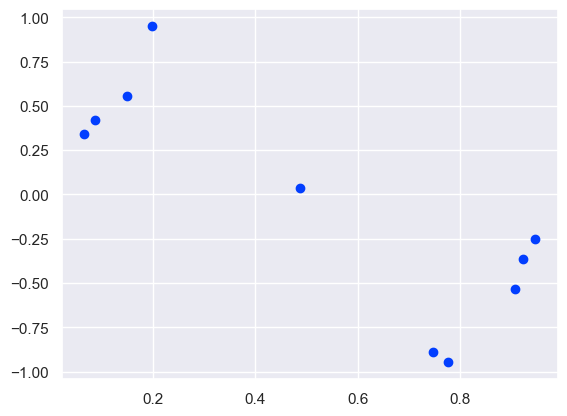

In [4]:
plt.scatter(x_train, y_train)

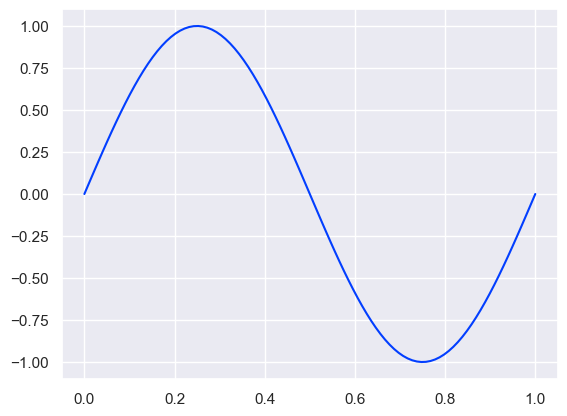

In [5]:
plt.plot(x_test, y_test, '-')

## 1) Linear models

### 1.1) Linear function

`linear` takes data point `x` and a list of `weights` as parameters

In [6]:
def linear(x, weights):
    result = 0

    for i, w in enumerate(weights):
        result += w * (x ** i)

    return result

### 1.2) Error function

`err` is a sum-of-squares error function that takes `weights`, `inputs` and `targets` as parameters

In [7]:
def err(weights, inputs, targets):
    result = 0

    for x, t in zip(inputs, targets):
        result += (linear(x, weights) - t) ** 2

    return 0.5 * result

### 1.3) Root meant square error

In [8]:
def erms(weights, inputs, targets):
    return (2 * err(weights, inputs, targets) / len(inputs)) ** 0.5

### 1.4) Optimization of Error function

`optimial_weights` takes `inputs`, `targets`, and `M` (number of weights) as parameters and returns optimal weights for this data

In [9]:
def optimial_weights(inputs, targets, M):
    N = len(inputs)
    X = np.array([[inputs[q] ** i for q in range(N)] for i in range(M + 1)])
    X_T = np.transpose(X)
    weights = np.linalg.inv(X @ X_T) @ X @ np.array(targets)
    return weights

### 1.5) Test the model

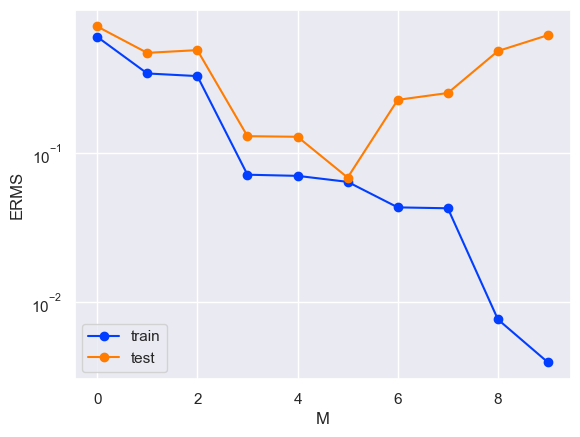

In [10]:
def test_all(start_M, end_M, x_train, y_train, x_test, y_test):

    results_train = []
    results_test = []
    all_weights = []

    for M in range(start_M, end_M + 1):
        weights = optimial_weights(x_train, y_train, M)
        all_weights.append(weights)
        error_train = erms(weights, x_train, y_train)
        error_test = erms(weights, x_test, y_test)
        results_train.append(error_train)
        results_test.append(error_test)
    return results_train, results_test, all_weights

r_tr, r_tt, all_weights = test_all(0, 9, x_train, y_train, x_test, y_test)

plt.plot(list(range(0, 10)), r_tr, '-o', label='train')
plt.plot(list(range(0, 10)), r_tt, '-o', label='test')
plt.xlabel('M')
plt.ylabel('ERMS')
plt.legend()
plt.yscale('log')

##### Weights table for different `M`

In [11]:
print(pd.DataFrame(all_weights))

          0           1            2             3             4  \
0 -0.067444         NaN          NaN           NaN           NaN   
1  0.674906   -1.403250          NaN           NaN           NaN   
2  0.870601   -2.937208     1.521622           NaN           NaN   
3 -0.348533   11.654727   -33.094539     22.088529           NaN   
4 -0.274931   10.447965   -27.877273     14.161034      3.897826   
5  0.052313    2.957062    24.077616   -126.364847    164.358999   
6  1.343704  -29.263447   282.780639  -1019.109604   1661.058677   
7  1.660035  -39.467068   401.667031  -1667.832646   3460.299324   
8 -2.482978  104.707919 -1467.193457  10141.202855 -36830.545014   
9 -1.499506   61.141094  -713.174253   3473.551083  -3718.825625   

              5             6              7             8             9  
0           NaN           NaN            NaN           NaN           NaN  
1           NaN           NaN            NaN           NaN           NaN  
2           NaN           

##### Estimated curve for `M=9` (same as the amount of data points)

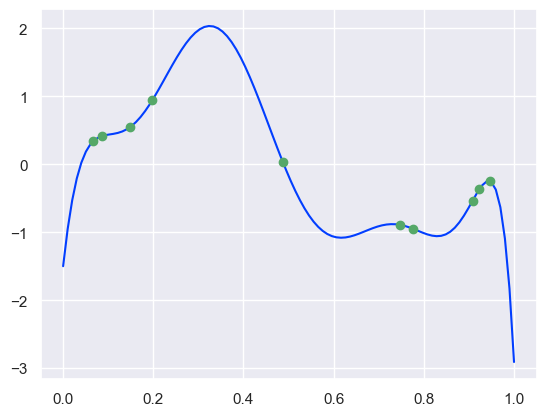

In [12]:
plt.plot(x_test, list(map(lambda x: linear(x, optimial_weights(x_train, y_train, 9)), x_test)), '-')
plt.plot(x_train, y_train, 'og')

## 2) Regularization

### 2.1) Error function

`err_regularization` takes `weights`, `inputs`, `targets` and `l` (regularization term) and computes sum-of-squares error with weights regularization

In [13]:
def err_regularization(weights, inputs, targets, l):
    result = 0

    #for x, t, w in zip(inputs, targets, weights):
    #    result += (linear(x, weights) - t) ** 2 + l/2 * w ** 2
    result = err(weights,inputs,targets) + l/2 * np.sum(weights**2)
    return 0.5 * result

`erms_regularization` is a regularization version of a root mean squares error

In [14]:
def erms_regularization(weights, inputs, targets, l):
    return (2 * err_regularization(weights, inputs, targets, l) / len(inputs)) ** 0.5

### 2.2) Optimization

`optimial_weights_regularization` takes `inputs`, `targets`, `M` (number of weights) and `l` (regularization term)  as parameters and returns optimal weights (with regularization) for this data

In [15]:
def optimial_weights_regularization(inputs, targets, M, l):
    N = len(inputs)
    X = np.array([[inputs[q] ** i for q in range(N)] for i in range(M + 1)])
    X_T = np.transpose(X)
    weights = np.linalg.inv(X @ X_T + l * np.identity(M + 1)) @ X @ np.array(targets)
    return weights

### 2.3) Test with regularization

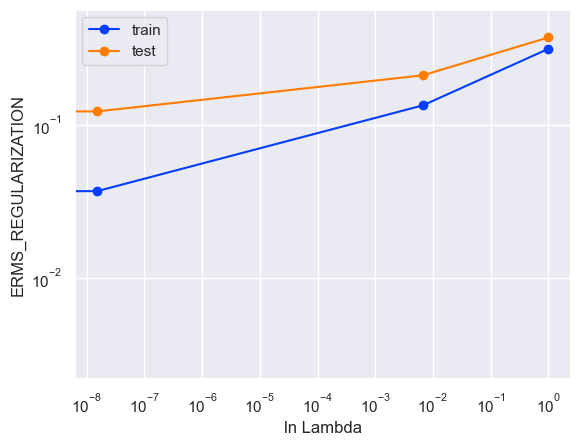

In [16]:
def test_all_regularization(ls, M, x_train, y_train, x_test, y_test):

    results_train = []
    results_test = []
    all_weights = []

    for l in ls:
        weights = optimial_weights_regularization(x_train, y_train, M, l)
        all_weights.append(weights)
        error_train = erms_regularization(weights, x_train, y_train, l)
        error_test = erms_regularization(weights, x_test, y_test, l)
        results_train.append(error_train)
        results_test.append(error_test)
    return results_train, results_test, all_weights

ls = [0, exp(-18), exp(-5), exp(0)]

r_tr_r, r_tt_r, all_weights_r = test_all_regularization(ls, 9, x_train, y_train, x_test, y_test)

plt.plot(ls, r_tr_r, '-o', label='train')
plt.plot(ls, r_tt_r, '-o', label='test')
plt.xlabel('ln Lambda')
plt.ylabel('ERMS_REGULARIZATION')
plt.legend()
plt.yscale('log')
plt.xscale('log')

##### Weights for `M=9` with regularization terms `0`, `exp(-18)`, `exp(-5)`, `exp(0)`

In [17]:
print(pd.DataFrame(np.transpose(all_weights_r)))

               0           1         2         3
0      -1.499506    0.699011  0.503543  0.328543
1      61.141094  -11.795682  0.743539 -0.389393
2    -713.174253  121.043844 -2.425527 -0.353466
3    3473.551083 -335.150176 -1.908122 -0.232935
4   -3718.825625  217.987059 -0.795824 -0.127092
5  -21952.756045  178.622534  0.106829 -0.046211
6   82383.881284  -87.722820  0.719266  0.013218
7 -118312.511569 -148.839191  1.096707  0.055948
8   79655.506742  -12.387885  1.302133  0.085993
9  -20878.222301   78.207421  1.385740  0.106489


In [18]:
def plot_by_lambda(l):
    plt.plot(x_test, y_test, '-r')
    plt.plot(x_test, list(map(lambda x: linear(x, optimial_weights_regularization(x_train, y_train, 9, l)), x_test)), '-')
    plt.plot(x_train, y_train, 'og')

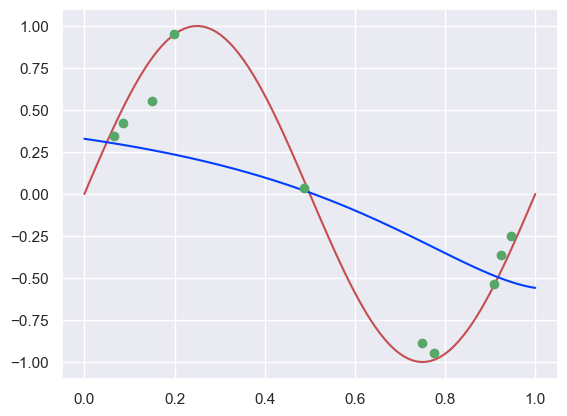

In [19]:
plot_by_lambda(exp(0))

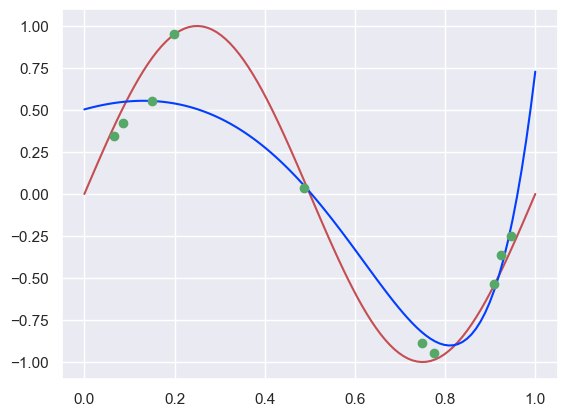

In [20]:
plot_by_lambda(exp(-5))

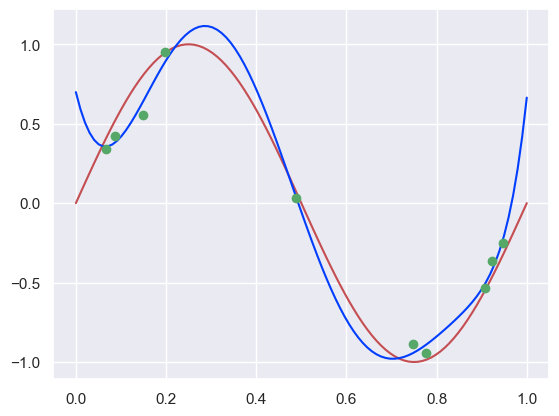

In [21]:
plot_by_lambda(exp(-18))

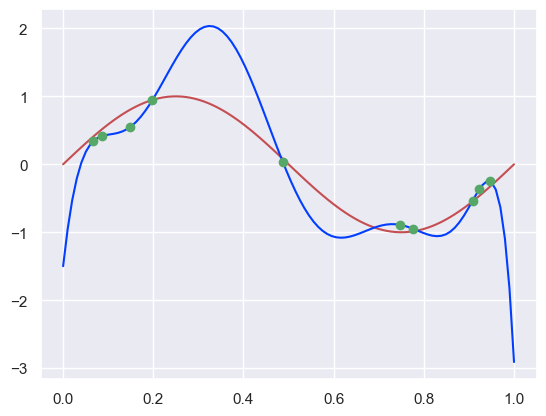

In [22]:
plot_by_lambda(0)

## 3) Model Selection

### 3.1) Cross-validation

`create_cross_validation_sets` takes `S` (number of sets) and data points `x_train`, `y_train` as parameters and returns array of sets in form `[x_sub_train, y_sub_train, x_validation, y_validation]` each

In [23]:
def create_cross_validation_sets(S, x_train, y_train):
   
    """
    Split (x_train, y_train) into S folds without shuffling.
    Returns list of (x_subtrain, y_subtrain, x_val, y_val).
    """
    x_train, y_train = np.asarray(x_train), np.asarray(y_train)
    N = len(x_train)
    idx = np.arange(N)

    folds = np.array_split(idx, S)
    sets = []
    for s in range(S):
        val_idx = folds[s]
        train_idx = np.concatenate([folds[i] for i in range(S) if i != s])
        sets.append((x_train[train_idx], y_train[train_idx],
                     x_train[val_idx], y_train[val_idx]))
    return sets


`best_model` takes `start_M`, `end_M` (low and high limits to search for `M`), `ls` (list of regularization terms) and `sets` (cross-validation sets) and should return `(top_M, top_l, top_result_test)` with `M`, `l` and result for the best model

M = 3 lambda = 0 CV ERMS = 0.08175332959159763


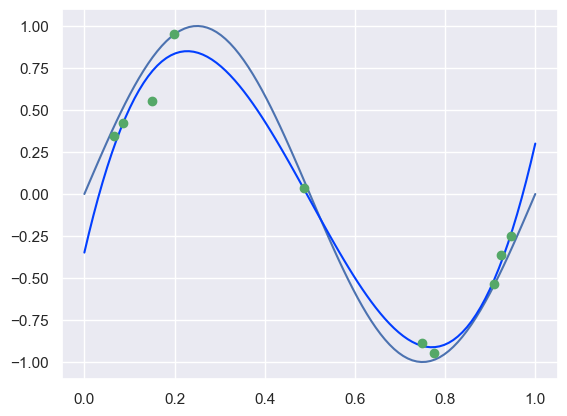

In [24]:
def best_model(start_M, end_M, ls, sets):
    """
    Grid-search over M in [start_M, end_M] and lambdas in ls using the
    provided cross-validation 'sets' (list of (x_sub, y_sub, x_val, y_val)).
    
    Returns:
        (best_M, best_lambda, best_mean_val_erms)
    """
    best_M = None
    best_l = None
    best_err = np.inf

    for M in range(start_M, end_M + 1):
        for l in ls:
            fold_errs = []
            for x_sub, y_sub, x_val, y_val in sets:
                # fit with ridge (regularized) on the sub-train fold
                w = optimial_weights_regularization(x_sub, y_sub, M, l)
                # score predictive error on the validation fold (NO regularization in the metric)
                fold_errs.append(erms(w, x_val, y_val))
            mean_val_err = float(np.mean(fold_errs))
            if mean_val_err < best_err:
                best_err = mean_val_err
                best_M = M
                best_l = l

    return best_M, best_l, best_err

# Use the ORIGINAL training set to build CV folds
sets = create_cross_validation_sets(10, x_train, y_train)

M, l, r = best_model(0, 9, [0, exp(-18), exp(-5), exp(0)], sets)
print('M =', M, 'lambda =', l, 'CV ERMS =', r)

# Retrain on full training set with the chosen hyperparams, then plot/predict
plt.plot(x_test, y_test, '-b')
plt.plot(x_test, [linear(x, optimial_weights_regularization(x_train, y_train, M, l)) for x in x_test], '-')
plt.plot(x_train, y_train, 'og')



## 4) Bayesian curve fitting

`phi` takes `x` (data point) and `M` (number of weights) as arguments and returns a vector of powers of `x` from `0` to `M`

In [26]:
def phi(x, M):
    result = []

    for i in range(M + 1):
        result.append(x ** i)

    return np.array(result).reshape(-1, 1)


`S` takes `alpha`, `beta`, `x` (all data points), and `M` as arguments and returns a matrix `S` that is used to compute `mean` and `variance`

In [27]:
def S(alpha, beta, x, M):
    I = np.identity(M + 1)

    sum = 0
    for x_i in x:
        phi_value = phi(x_i, M)
        sum += phi_value @ np.transpose(phi_value)

    result = alpha * I + beta * sum
    return np.linalg.inv(result)


`mean` takes `alpha`, `beta`, `x_star` (new point), `x` (all data points), `t` (target values), and `M` and computes mean for the Gaussian distribution

In [28]:
def mean(alpha, beta, x_star, x, t, M):
    sum = 0

    for x_i, t_i in zip(x, t):
        sum += phi(x_i, M) * t_i
    result = beta * (np.transpose(phi(x_star, M)) @ S(alpha, beta, x, M) @ sum)
    return result.reshape(1)[0]


`variance` takes `alpha`, `beta`, `x_star` (new point), `x` (all data points), `t` (target values), and `M` and computes mean for the Gaussian variance

In [29]:
def variance(alpha, beta, x_star, x, t, M):
    phi_value = phi(x_star, M)
    result = (1/beta) * (np.transpose(phi_value) @ S(alpha, beta, x, M) @ phi_value)
    return result.reshape(1)[0]

### 4.1) Display results

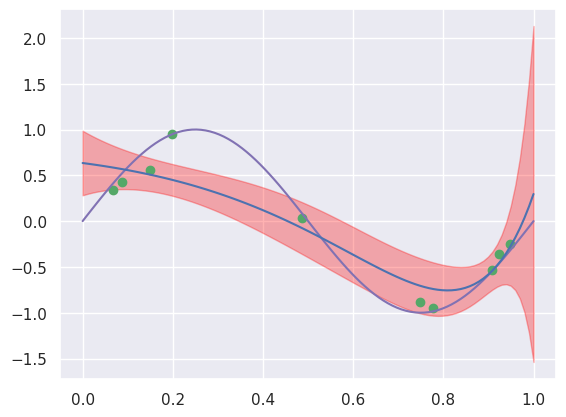

In [31]:
alpha = 0.05
beta = 1.1
M = 9

means = np.array(list(map(lambda x: mean(alpha, beta, x, x_train, y_train, M), x_test)))
variances = np.array(list(map(lambda x: variance(alpha, beta, x, x_train, y_train, M), x_test)))

plt.plot(x_train, y_train, 'og')
plt.plot(x_test, y_test, '-m')
plt.plot(x_test, means, '-b')
plt.fill_between(x_test, means + variances, means - variances, color='red', alpha=0.3)